In [1]:
import os
import torch
import torch.nn as nn
import numpy as np
from AIce.functions import testloader,redim,getRMSE
from  AIce.models import NNforNorms
from AIce.plotting import ResidualOnTheMap,PredAgainstTarget

In [14]:
device='cuda'
allinput=['u_ERA5','v_ERA5','h_piomas','sic_CDR','x_EASE','y_EASE','bath','sin','cos', 'windnorm']
lst=['u_ERA5', 'v_ERA5', 'h_piomas', 'sic_CDR', 'windnorm']
weightpath='../August/weights/NNforNorms_5inputs_20E_0.001lr_26-15h_44m_21s.pt'

gangtestdata,_,_,means,stds,maxes,labels=testloader('../data/DRIFT_DATA_TEST.csv',inputlist=allinput ,target='buoynorm',
                                trainingset_loaded=False, training_file='../data/DRIFT_DATA_TRAIN.csv')# Get the means,stds,maxes using the longest list possible

modeldata,_,_,_,_,_,_=testloader('../data/DRIFT_DATA_TEST.csv',inputlist=lst ,target='buoynorm',
                             trainingset_loaded=True, means=means,stds=stds,maxes=maxes)# Get the means,stds,maxes using the longest list possible

mlp256= NNforNorms(len(lst)).to(device) # Creates a model for the specific n_inputs
mlp256.load_state_dict(torch.load(weightpath, weights_only=True))# loads the weights onto the model
mlp256.eval()  # if you're doing inference, not continuing training

out=mlp256(torch.tensor(modeldata.drop(['buoynorm'], axis=1).values, dtype= torch.float32).to(device)).to('cpu')# runs the data into the model 
# testdata=redim(testdata,
#                means=means,
#                stds=stds,
#                maxes=maxes)
testdata['usual+windnorm']=np.expm1(out.detach().numpy()) # save the model prediction in the datapd with name associated to n_inputs


Bath size is the full test set
Target is buoynorm normalized by log1p
Sin and Cos added
Bathymetry (bath) normalized by maximum
x/y (x_EASE, y_EASE) normalized by maximum
Windnorm normalized by z-score
Wind components (u/v_ERA5) normalized by z-score
Bath size is the full test set
Target is buoynorm normalized by log1p
Windnorm normalized by z-score
Wind components (u/v_ERA5) normalized by z-score


Index(['buoynorm', 'x_EASE', 'y_EASE', 'u_ERA5', 'v_ERA5', 'sic_CDR',
       'h_piomas', 'sin', 'cos', 'bath', 'windnorm', 'bath+wind', 'bathnowind',
       'usual', 'usual+windnorm'],
      dtype='object')


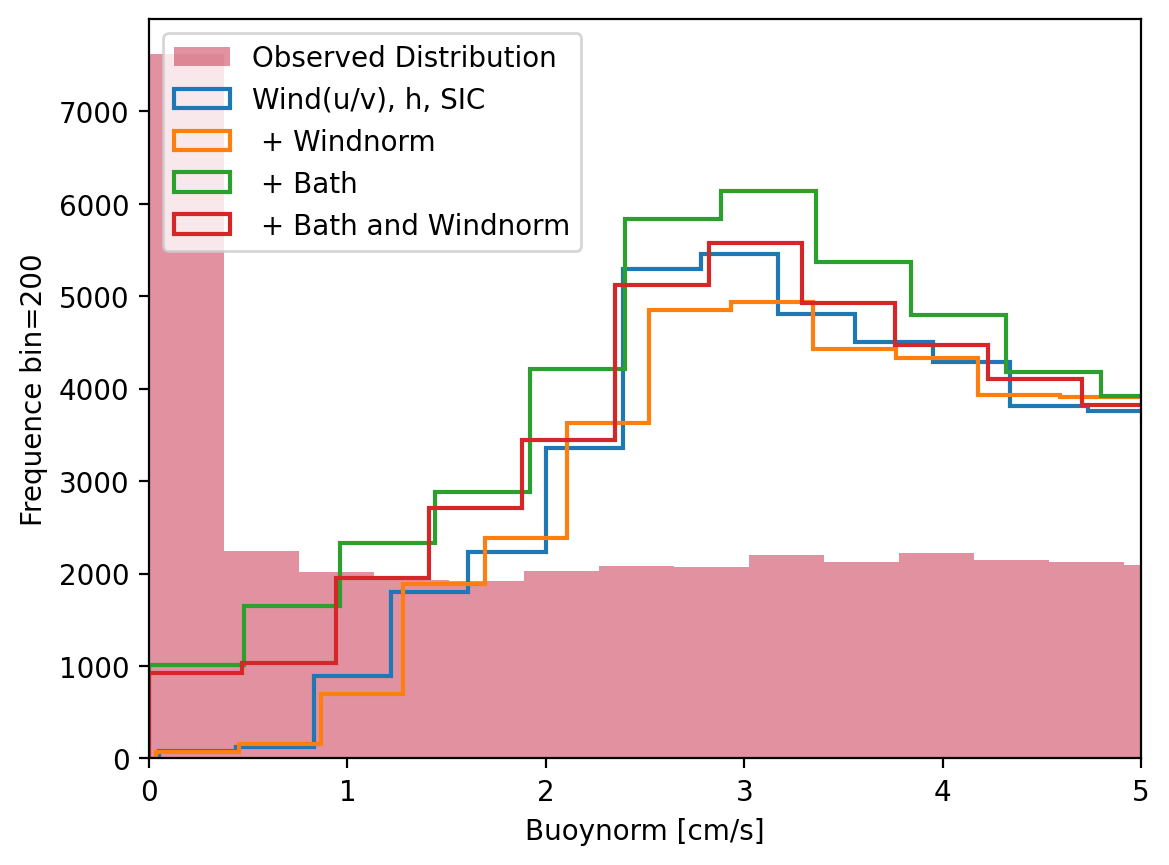

In [30]:
import matplotlib.pyplot as plt
print(testdata.columns)
# rmse=getRMSE(testdata['buoynorm'].values, testdata['output'].values)
# print('Rmse: ', rmse)
# PredAgainstTarget(testdata['buoynorm'], testdata['output'], testdata['windnorm'])
# ResidualOnTheMap(testdata,'output', 'buoynorm')


fig, ax =plt.subplots(dpi=200)
n_bins=200
lw=1.5
ax.hist(testdata['buoynorm'], n_bins, color= "#C52C4684", label='Observed Distribution')
ax.hist(testdata['usual'], n_bins, histtype='step', linewidth=lw, label='Wind(u/v), h, SIC')
ax.hist(testdata['usual+windnorm'], n_bins, histtype='step',linewidth=lw, #linestyle='--', 
        label=' + Windnorm')
ax.hist(testdata['bathnowind'], n_bins, histtype='step',linewidth=lw, #linestyle='dotted', 
        label=' + Bath')
ax.hist(testdata['bath+wind'], n_bins, histtype='step', linewidth=lw, #linestyle='-.', 
        label=' + Bath and Windnorm')



ax.legend()
#plt.xlim([-np.pi,np.pi])
ax.set_xlim([-0,5])
ax.set_ylabel(f'Frequence bin={n_bins}')
ax.set_xlabel('Buoynorm [cm/s]')
ax.legend()
plt.show()


